# Зертханалық жұмыс № 1. ЖИ-жобасының әзірлеу ортасын баптау

**Жұмыстың мақсаты:** ЖИ-жобасын әзірлеуге арналған жұмыс ортасын баптау, Python мен деректерді талдау және машиналық оқыту кітапханаларының жұмысын тексеру, жобаның Git-репозиторийін құру.

**Орындау тәртібі (Google Colab):**
1. Ноутбукты Colab-та ашыңыз.
2. Git үшін атыңыз бен email-іңізді 10-жаттығудағы ұяшықта көрсетіңіз.
3. **Орындау → Барлығын орындау** (Runtime → Run all) басыңыз.
4. Google Drive-қа рұқсат сұралғанда келісіңіз: жоба `MyDrive/ai_project` папкасында сақталады және сессия жабылғанда жоғалмайды.

## 0. Жоба папкасын дайындау

In [4]:
import os, sys, json, subprocess

USE_DRIVE = True  # False болса, жоба /content ішінде уақытша құрылады

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

drive_mounted = False
if IN_COLAB and USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=True)
        PROJECT_DIR = '/content/drive/MyDrive/ai_project'
        drive_mounted = True
    except Exception as e:
        print("Google Drive-қа қосылу сәтсіз аяқталды:", e)
        print("Жоба уақытша /content/ai_project ішінде құрылады.")

if not drive_mounted:
    if IN_COLAB:
        PROJECT_DIR = '/content/ai_project'
    else:
        PROJECT_DIR = os.path.abspath('ai_project')

os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Colab ортасы:", IN_COLAB)
print("Жоба папкасы:", os.getcwd())

Mounted at /content/drive
Colab ортасы: True
Жоба папкасы: /content/drive/MyDrive/ai_project


## 1-жаттығу. Python нұсқасын тексеру

In [5]:
print(sys.version)
assert sys.version_info >= (3, 10), "Python 3.10 немесе одан жоғары нұсқа қажет"
print("Python нұсқасы талапқа сай:", f"{sys.version_info.major}.{sys.version_info.minor}")

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Python нұсқасы талапқа сай: 3.13


## 2-жаттығу. Жоба құрылымын құру

In [6]:
folders = ["data", "notebooks", "src", "models", "reports"]
for f in folders:
    os.makedirs(f, exist_ok=True)
    # Git бос папкаларды бақыламайды, сондықтан әрқайсысына .gitkeep қоямыз
    open(os.path.join(f, ".gitkeep"), "a").close()

for f in ["requirements.txt", "README.md", ".gitignore"]:
    if not os.path.exists(f):
        open(f, "w").close()

def show_tree(path=".", prefix=""):
    items = sorted(i for i in os.listdir(path) if i not in (".git", "venv", ".gitkeep", ".ipynb_checkpoints"))
    items.sort(key=lambda i: not os.path.isdir(os.path.join(path, i)))
    for n, name in enumerate(items):
        last = n == len(items) - 1
        full = os.path.join(path, name)
        print(prefix + ("└── " if last else "├── ") + name + ("/" if os.path.isdir(full) else ""))
        if os.path.isdir(full) and path == ".":
            show_tree(full, prefix + ("    " if last else "│   "))

print("ai_project/")
show_tree()

ai_project/
├── data/
├── models/
├── notebooks/
├── reports/
├── src/
├── .gitignore
├── README.md
└── requirements.txt


**Папкалар мен файлдардың мақсаты:**

| Элемент | Мақсаты |
|---|---|
| `data/` | Бастапқы және өңделген деректер жиындары (CSV, Excel т.б.) |
| `notebooks/` | Зерттеу мен тәжірибелерге арналған Jupyter Notebook файлдары |
| `src/` | Жобаның қайта қолданылатын Python коды (модульдер, функциялар) |
| `models/` | Оқытылған модельдер және олардың салмақтары |
| `reports/` | Графиктер, суреттер, есептер |
| `requirements.txt` | Жоба тәуелділіктерінің тізімі мен нұсқалары |
| `README.md` | Жобаның сипаттамасы және іске қосу нұсқаулығы |
| `.gitignore` | Git бақыламайтын файлдар тізімі |

## 3-жаттығу. Виртуалды орта құру

Жергілікті компьютерде виртуалды орта былай құрылады және белсендіріледі:

```bash
python -m venv venv
venv\Scripts\activate        # Windows
source venv/bin/activate      # Linux немесе macOS
```

**Colab ерекшелігі:** Colab-тағы әр сессия онсыз да бөлек, оқшауланған виртуалды машинада жұмыс істейді. `!` арқылы орындалатын әр команда жаңа shell-де іске қосылатындықтан, `activate` келесі ұяшықтарға сақталмайды. Сондықтан төменде `venv` тек құрылады және тексеріледі, ал кітапханалар Colab ортасына орнатылады. `venv/` папкасы `.gitignore` арқылы репозиторийге қосылмайды.

In [7]:
r = subprocess.run([sys.executable, "-m", "venv", "venv"], capture_output=True, text=True)
if r.returncode != 0:
    # Colab-та ensurepip жоқ болуы мүмкін, сондықтан pip-сіз құрамыз
    r = subprocess.run([sys.executable, "-m", "venv", "--without-pip", "venv"], capture_output=True, text=True)
print("venv құрылды" if r.returncode == 0 else "Қате: " + r.stderr)
venv_python = "venv/Scripts/python.exe" if os.name == "nt" else "venv/bin/python"
print("venv ішіндегі Python:", subprocess.run([venv_python, "--version"], capture_output=True, text=True).stdout.strip())

venv құрылды
venv ішіндегі Python: Python 3.13.15


## 4-жаттығу. Кітапханаларды орнату

In [8]:
# Colab-та Jupyter кіріктірілген, сондықтан оны тек жергілікті ортада орнатамыз
pkgs = "numpy pandas matplotlib scikit-learn" + ("" if IN_COLAB else " jupyter")
%pip install -q {pkgs}

In [9]:
import numpy as np
import pandas as pd
import matplotlib
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 2.1.3
Pandas: 2.2.3
Matplotlib: 3.10.0
Scikit-learn: 1.6.1


**requirements.txt туралы:** Colab-та `pip freeze` жүздеген алдын ала орнатылған пакетті шығарады, олардың көбі жобаға қатысы жоқ. Сондықтан толық тізімнің көлемін көрсетеміз, ал `requirements.txt` файлына жобада нақты қолданылатын кітапханаларды нұсқаларымен жазамыз. Жергілікті ортада `pip freeze > requirements.txt` командасы тікелей қолданылады.

In [10]:
freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout.splitlines()
print("pip freeze бойынша пакеттер саны:", len(freeze))

from importlib.metadata import version
main_pkgs = ["numpy", "pandas", "matplotlib", "scikit-learn"]
with open("requirements.txt", "w") as f:
    for p in main_pkgs:
        f.write(f"{p}=={version(p)}\n")
    f.write("jupyter\n")
print(open("requirements.txt").read())

pip freeze бойынша пакеттер саны: 642
numpy==2.1.3
pandas==2.2.3
matplotlib==3.10.0
scikit-learn==1.6.1
jupyter



## 5-жаттығу. NumPy-мен жұмыс

In [11]:
numbers = np.arange(1, 11)
print("Массив:", numbers)
print("1. Элементтер қосындысы:", numbers.sum())
print("2. Орташа мән:", numbers.mean())
print("3. Минимум:", numbers.min(), "| Максимум:", numbers.max())
print("4. Әр элемент × 2:", numbers * 2)
print("5. 5-тен үлкен элементтер:", numbers[numbers > 5])

Массив: [ 1  2  3  4  5  6  7  8  9 10]
1. Элементтер қосындысы: 55
2. Орташа мән: 5.5
3. Минимум: 1 | Максимум: 10
4. Әр элемент × 2: [ 2  4  6  8 10 12 14 16 18 20]
5. 5-тен үлкен элементтер: [ 6  7  8  9 10]


## 6-жаттығу. Pandas-пен жұмыс

In [12]:
df = pd.DataFrame({
    "Студент": ["Алия", "Данияр", "Мадина", "Арман", "Айжан"],
    "Жасы": [19, 20, 18, 21, 20],
    "Балл": [85, 78, 92, 74, 88],
})

print("2. Алғашқы жолдар:")
display(df.head())

print("3. Орташа балл:", df["Балл"].mean())

print("4. Балы 80-нен жоғары студенттер:")
display(df[df["Балл"] > 80])

PASS_SCORE = 80  # сынақтан өту шегі
df["Нәтиже"] = np.where(df["Балл"] >= PASS_SCORE, "Есептелді", "Есептелмеді")
print("5. «Нәтиже» бағаны қосылды:")
display(df)

df.to_csv("data/students.csv", index=False, encoding="utf-8-sig")
print("6. Кесте сақталды: data/students.csv")

2. Алғашқы жолдар:


,Студент,Жасы,Балл
0,Алия,19,85
1,Данияр,20,78
2,Мадина,18,92
3,Арман,21,74
4,Айжан,20,88


3. Орташа балл: 83.4
4. Балы 80-нен жоғары студенттер:


,Студент,Жасы,Балл
0,Алия,19,85
2,Мадина,18,92
4,Айжан,20,88


5. «Нәтиже» бағаны қосылды:


,Студент,Жасы,Балл,Нәтиже
0,Алия,19,85,Есептелді
1,Данияр,20,78,Есептелмеді
2,Мадина,18,92,Есептелді
3,Арман,21,74,Есептелмеді
4,Айжан,20,88,Есептелді


6. Кесте сақталды: data/students.csv


## 7-жаттығу. Деректерді визуализациялау

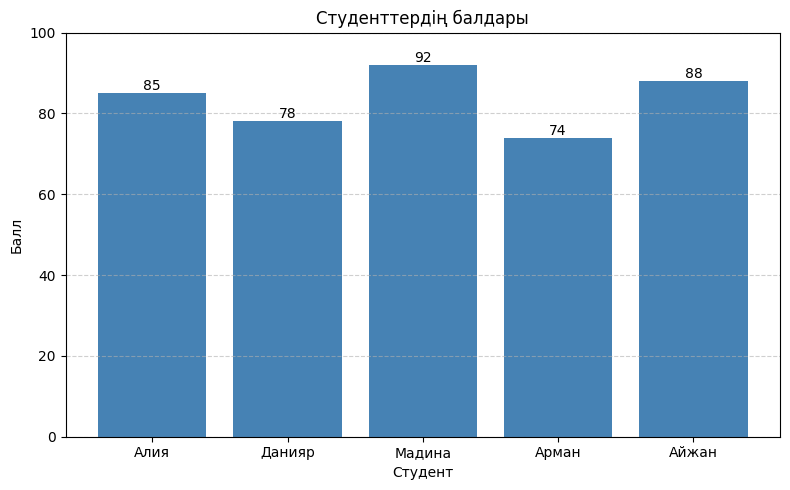

График сақталды: reports/student_scores.png


In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
bars = plt.bar(df["Студент"], df["Балл"], color="steelblue")
plt.bar_label(bars)
plt.title("Студенттердің балдары")
plt.xlabel("Студент")
plt.ylabel("Балл")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("reports/student_scores.png", dpi=150)
plt.show()
print("График сақталды: reports/student_scores.png")

## 8-жаттығу. Scikit-learn-дегі алғашқы модель

In [14]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

try:
    # 1. Деректерді жүктеу
    iris = load_iris()
    X, y = iris.data, iris.target
    print("Деректер көлемі:", X.shape, "| Кластар:", [str(n) for n in iris.target_names])

    # 2. Оқыту және тест жиындарына бөлу
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 3. Логистикалық регрессияны оқыту
    model = LogisticRegression(max_iter=500)
    model.fit(X_train, y_train)

    # 4. Болжам алу
    predictions = model.predict(X_test)

    # 5. Дәлдікті есептеу
    accuracy = accuracy_score(y_test, predictions)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Тест жиынында {len(y_test)} үлгінің {int((predictions == y_test).sum())}-і дұрыс жіктелді")
    print(classification_report(y_test, predictions, target_names=iris.target_names))
except ValueError as e:
    print("Деректер немесе параметрлер қатесі:", e)
except Exception as e:
    print("Модельді оқыту кезінде күтпеген қате:", type(e).__name__, e)

Деректер көлемі: (150, 4) | Кластар: ['setosa', 'versicolor', 'virginica']
Accuracy: 0.9667
Тест жиынында 30 үлгінің 29-і дұрыс жіктелді
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



**Нәтижені түсіндіру:** Iris деректер жиынында 150 гүл үлгісі және 4 белгі бар (тостағанша және күлтенің ұзындығы мен ені), кластар саны 3. Модель деректердің 80%-ында оқытылып, қалған 20%-ында (30 үлгі) тексерілді. Accuracy мәні дұрыс жіктелген үлгілердің үлесін көрсетеді. Iris класстары белгілер бойынша жақсы ажыратылатындықтан, тіпті қарапайым логистикалық регрессия өте жоғары дәлдік береді. Тест жиыны шағын болғандықтан, бір қате дәлдікті шамамен 3,3%-ға төмендетеді, сондықтан нәтижені сенімді бағалау үшін кросс-валидация қолданған дұрыс.

`try/except` блогы деректерді жүктеу немесе модельді оқыту кезіндегі қателерді ұстап, бағдарламаның апатты тоқтауының орнына түсінікті хабарлама шығарады.

## 9-жаттығу. Jupyter Notebook

Осы ноутбуктың өзі талап етілген барлық бөлімді қамтиды: атауы, мақсаты, Python нұсқасын тексеру, кітапханаларды тексеру, NumPy, Pandas, визуализация, Scikit-learn моделі және қорытынды. Төмендегі ұяшық оның көшірмесін `notebooks/lab01_environment.ipynb` ретінде сақтайды.

In [15]:
NB_PATH = "notebooks/lab01_environment.ipynb"

def save_notebook_copy(path=NB_PATH):
    if not IN_COLAB:
        print("Жергілікті орта: ноутбукты", path, "ретінде сақтаңыз")
        return os.path.exists(path)
    try:
        from google.colab import _message
        nb = _message.blocking_request("get_ipynb", request="", timeout_sec=30)["ipynb"]
        with open(path, "w", encoding="utf-8") as f:
            json.dump(nb, f, ensure_ascii=False, indent=1)
        print("Ноутбук сақталды:", path)
        return True
    except Exception as e:
        print("Автоматты сақтау мүмкін болмады:", e)
        print("Файл → Жүктеп алу → .ipynb арқылы жүктеп, notebooks/ папкасына салыңыз")
        return False

_ = save_notebook_copy()

Ноутбук сақталды: notebooks/lab01_environment.ipynb


## 10-жаттығу. Git баптау

In [16]:
gitignore = """venv/
__pycache__/
.ipynb_checkpoints/
*.pyc
.env
"""
with open(".gitignore", "w") as f:
    f.write(gitignore)
print(open(".gitignore").read())

venv/
__pycache__/
.ipynb_checkpoints/
*.pyc
.env



In [17]:
GIT_NAME = "Nursultan"               # өз атыңыз
GIT_EMAIL = "nursultan@example.com"  # өз email-іңіз

!git init -b main
!git config user.name "{GIT_NAME}"
!git config user.email "{GIT_EMAIL}"
!git config core.fileMode false
!git status

Initialized empty Git repository in /content/drive/MyDrive/ai_project/.git/
On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore
	README.md
	data/
	models/
	notebooks/
	reports/
	requirements.txt
	src/

nothing added to commit but untracked files present (use "git add" to track)


In [18]:
_ = save_notebook_copy()
!git add .
!git commit -m "Initial project setup"
!git log --oneline

Ноутбук сақталды: notebooks/lab01_environment.ipynb
[main (root-commit) 624c290] Initial project setup
 11 files changed, 1686 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 README.md
 create mode 100644 data/.gitkeep
 create mode 100644 data/students.csv
 create mode 100644 models/.gitkeep
 create mode 100644 notebooks/.gitkeep
 create mode 100644 notebooks/lab01_environment.ipynb
 create mode 100644 reports/.gitkeep
 create mode 100644 reports/student_scores.png
 create mode 100644 requirements.txt
 create mode 100644 src/.gitkeep
624c290 (HEAD -> main) Initial project setup


## 11-жаттығу. README дайындау

In [19]:
readme = """# ai_project

## Сипаттамасы
ЖИ-жобасының оқу репозиторийі. Зертханалық жұмыс № 1 аясында әзірлеу ортасы бапталды:
Python мен негізгі кітапханалар тексерілді, деректермен жұмыс, визуализация және
алғашқы машиналық оқыту моделі (Iris, логистикалық регрессия) орындалды.

## Технологиялар
- Python 3.10+
- NumPy, Pandas
- Matplotlib
- Scikit-learn
- Jupyter Notebook / Google Colab
- Git

## Орнату
```bash
git clone <репозиторий-сілтемесі>
cd ai_project
python -m venv venv
venv\\Scripts\\activate        # Windows
source venv/bin/activate      # Linux / macOS
pip install -r requirements.txt
```

## Jupyter Notebook іске қосу
Жергілікті түрде:
```bash
jupyter notebook notebooks/lab01_environment.ipynb
```
Немесе ноутбукты Google Colab-та ашып, **Runtime → Run all** басыңыз.

## Папкалар құрылымы
```
ai_project/
├── data/            деректер жиындары
├── notebooks/       Jupyter Notebook файлдары
├── src/             жоба коды
├── models/          оқытылған модельдер
├── reports/         графиктер мен есептер
├── requirements.txt тәуелділіктер
├── README.md        жоба сипаттамасы
└── .gitignore       Git бақыламайтын файлдар
```

## Автор
Нұрсұлтан, Л.Н. Гумилев атындағы Еуразия ұлттық университеті,
Цифрлық ғылымдар және жасанды интеллект институты.
"""
with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)
print(readme)

# ai_project

## Сипаттамасы
ЖИ-жобасының оқу репозиторийі. Зертханалық жұмыс № 1 аясында әзірлеу ортасы бапталды:
Python мен негізгі кітапханалар тексерілді, деректермен жұмыс, визуализация және
алғашқы машиналық оқыту моделі (Iris, логистикалық регрессия) орындалды.

## Технологиялар
- Python 3.10+
- NumPy, Pandas
- Matplotlib
- Scikit-learn
- Jupyter Notebook / Google Colab
- Git

## Орнату
```bash
git clone <репозиторий-сілтемесі>
cd ai_project
python -m venv venv
venv\Scripts\activate        # Windows
source venv/bin/activate      # Linux / macOS
pip install -r requirements.txt
```

## Jupyter Notebook іске қосу
Жергілікті түрде:
```bash
jupyter notebook notebooks/lab01_environment.ipynb
```
Немесе ноутбукты Google Colab-та ашып, **Runtime → Run all** басыңыз.

## Папкалар құрылымы
```
ai_project/
├── data/            деректер жиындары
├── notebooks/       Jupyter Notebook файлдары
├── src/             жоба коды
├── models/          оқытылған модельдер
├── reports/         графикт

In [ ]:
_ = save_notebook_copy()
!git add .
!git commit -m "Add README"
!git log --oneline

## 12-жаттығу. Ортаны қорытынды тексеру

In [ ]:
def run(cmd):
    return subprocess.run(cmd, shell=True, capture_output=True, text=True)

def can_import(*mods):
    try:
        for m in mods:
            __import__(m)
        return True
    except ImportError:
        return False

commits = run("git rev-list --count HEAD").stdout.strip()
checks = {
    "Python іске қосылады": sys.version_info >= (3, 10),
    "Кітапханалар импортталады": can_import("numpy", "pandas", "matplotlib", "sklearn"),
    "Jupyter Notebook ашылады": IN_COLAB or can_import("notebook") or can_import("jupyterlab"),
    "Кестелер құрылады (data/students.csv)": os.path.exists("data/students.csv"),
    "Графиктер құрылады (reports/student_scores.png)": os.path.exists("reports/student_scores.png"),
    "Модель оқытылады": "accuracy" in globals() and accuracy > 0,
    "requirements.txt құрылған": os.path.getsize("requirements.txt") > 0,
    "Git жұмыс істейді": run("git --version").returncode == 0,
    "Алғашқы коммит орындалған": commits.isdigit() and int(commits) >= 1,
}
for name, ok in checks.items():
    print(("✅" if ok else "❌"), name)
print(f"\nНәтиже: {sum(checks.values())}/{len(checks)} тексеріс өтті | Коммиттер саны: {commits}")

## Бақылау сұрақтарына жауаптар

**1. Виртуалды орта не үшін қолданылады?**
Жобаның кітапханаларын жүйелік Python мен басқа жобалардан оқшаулау үшін. Әр жоба кітапханалардың өз нұсқаларын қолданады, нұсқалар арасында қақтығыс болмайды және ортаны басқа компьютерде қайта құру жеңілдейді.

**2. NumPy мен Pandas қандай рөл атқарады?**
NumPy көпөлшемді массивтермен жылдам сандық есептеулер жүргізеді: векторлық операциялар, статистика, сызықтық алгебра. Pandas NumPy негізінде құрылған және кестелік деректермен (DataFrame) жұмыс істейді: файлдарды оқу мен жазу, сүзу, топтау, деректерді тазалау.

**3. Matplotlib не үшін қолданылады?**
Графиктер мен диаграммалар салу үшін: деректерді зерттеу, заңдылықтарды көрсету және нәтижелерді есептерге сурет ретінде сақтау.

**4. Scikit-learn қандай міндеттерді шешеді?**
Классикалық машиналық оқыту міндеттерін: классификация, регрессия, кластерлеу, өлшемділікті төмендету. Сонымен қатар деректерді алдын ала өңдеу, жиындарды бөлу, сапа метрикаларын есептеу және модель таңдау құралдарын береді.

**5. requirements.txt файлы не үшін керек?**
Онда жобаға қажетті кітапханалар мен олардың нұсқалары жазылады. `pip install -r requirements.txt` командасы арқылы дәл сондай ортаны кез келген компьютерде бір әрекетпен қайта құруға болады.

**6. Jupyter Notebook қарапайым Python скриптінен немен ерекшеленеді?**
Notebook ұяшықтардан тұрады: кодты бөліктеп орындауға, нәтижелер мен графиктерді код жанында көруге және мәтіндік түсініктемелер қосуға болады. Бұл зерттеу, тәжірибе және есеп үшін ыңғайлы. Скрипт (.py) басынан аяғына дейін толық орындалады, автоматтандыру мен өнімдік код үшін қолайлы және Git-те өзгерістерін бақылау оңай.

**7. Git не үшін қолданылады?**
Нұсқаларды басқару үшін: өзгерістер тарихын сақтайды, алдыңғы нұсқаға қайтуға, тармақтармен жұмыс істеуге, командада бірлесіп әзірлеуге және кодты GitHub сияқты қашықтағы репозиторийге жариялауға мүмкіндік береді.

**8. .gitignore файлына қандай файлдарды қосу керек?**
Қайта құруға болатын немесе құпия файлдарды: виртуалды орта (`venv/`), кэш (`__pycache__/`, `*.pyc`), ноутбук checkpoint-тері (`.ipynb_checkpoints/`), құпия кілттер (`.env`), сондай-ақ үлкен деректер жиындары, модель салмақтары және IDE баптаулары.

## Қорытынды

Жұмыс барысында Google Colab-та ЖИ-жобасын әзірлеу ортасы бапталды. Python нұсқасы талапқа (3.10+) сай екені тексерілді, NumPy, Pandas, Matplotlib және Scikit-learn кітапханалары сәтті импортталды, олардың нұсқалары `requirements.txt` файлына жазылды. Жобаның стандартты құрылымы (`data`, `notebooks`, `src`, `models`, `reports`) құрылды.

NumPy көмегімен массивтермен негізгі операциялар, Pandas көмегімен студенттер кестесін құру, сүзу және CSV-ға сақтау орындалды, Matplotlib арқылы балдар диаграммасы салынып, `reports` папкасына сақталды. Iris деректерінде логистикалық регрессия моделі оқытылып, оның дәлдігі бағаланды.

Соңында Git-репозиторий құрылып, `.gitignore` және `README.md` файлдары дайындалып, коммиттер орындалды. Қорытынды тексерістің барлық пункті орындалды, яғни орта ЖИ-жобасын ары қарай әзірлеуге дайын.